In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv('attendance.csv')

In [6]:
print(df.head())

   Student_Number              Student_Name  DBMS  TOC  SPOS  CNS  IOT  DBMSL  \
0               1      GHOGARE YASHRAJ ANIL    10   10     4   10   11      4   
1               2  GHULE UMESH PANDHARINATH     6    8     3    6    5      3   
2               3      GIRAMKAR YOGESH BALU     7    7     3    7    8      4   
3               4      GIRI VIJAY PANDURANG     3    1     1    0    7      1   
4               5      GOSAVI DIPTI BAPURAO    12   19     7   17   15      9   

   CSNL  LPI  Total  Average  
0     1    0     50    37.31  
1     4    1     36    26.87  
2     5    0     41    30.60  
3     1    0     14    10.45  
4     4    7     90    67.16  


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_Number  77 non-null     int64  
 1   Student_Name    77 non-null     object 
 2   DBMS            77 non-null     int64  
 3   TOC             77 non-null     int64  
 4   SPOS            77 non-null     int64  
 5   CNS             77 non-null     int64  
 6   IOT             77 non-null     int64  
 7   DBMSL           77 non-null     int64  
 8   CSNL            77 non-null     int64  
 9   LPI             77 non-null     int64  
 10  Total           77 non-null     int64  
 11  Average         77 non-null     float64
dtypes: float64(1), int64(10), object(1)
memory usage: 7.3+ KB
None


In [8]:
print(df[['DBMS', 'Total', 'Average']].describe())

            DBMS      Total    Average
count  77.000000  77.000000  77.000000
mean    8.272727  54.922078  40.986623
std     4.494547  28.082475  20.956055
min     0.000000   0.000000   0.000000
25%     5.000000  36.000000  26.870000
50%     9.000000  62.000000  46.270000
75%    12.000000  76.000000  56.720000
max    15.000000  96.000000  71.640000


In [9]:
df_clean = df[(df['DBMS'] > 0) & (df['Total'] > 0)].copy()
X = df_clean[['DBMS']].values
y = df_clean['Total'].values


In [10]:
print(f"\nX (DBMS attendance) shape: {X.shape}")
print(f"\nX (total attendance) shape: {y.shape}")


X (DBMS attendance) shape: (70, 1)

X (total attendance) shape: (70,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

Training set: 56 samples
Testing set: 14 samples


In [12]:
model = LinearRegression()
model.fit(X_train, y_train) #train the x and y data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (b): {intercept:.4f}")
print(f"\nEquation: Total = {slope:.4f} × DBMS + {intercept:.4f}")


Slope (m): 5.5784
Intercept (b): 9.6436

Equation: Total = 5.5784 × DBMS + 9.6436


In [14]:
# predictions
y_train_prediction = model.predict(X_train)
y_test_prediction = model.predict(X_test)

print("\nTest Set Predictions (First 5):")
print("-" * 40)
for i in range(min(5, len(X_test))):
    print(f"DBMS: {X_test[i][0]:2.0f} | Actual: {y_test[i]:3.0f} | Predicted: {y_test_prediction[i]:3.0f}")



Test Set Predictions (First 5):
----------------------------------------
DBMS:  7 | Actual:  61 | Predicted:  49
DBMS: 10 | Actual:  50 | Predicted:  65
DBMS:  9 | Actual:  51 | Predicted:  60
DBMS: 12 | Actual:  90 | Predicted:  77
DBMS: 10 | Actual:  76 | Predicted:  65


In [15]:
r2_train = r2_score(y_train, y_train_prediction)
r2_test = r2_score(y_test, y_test_prediction)

# Mean Squared Error
mse_train = mean_squared_error(y_train, y_train_prediction)
mse_test = mean_squared_error(y_test, y_test_prediction)

# Root Mean Squared Error
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print(f"Training Set Performance:")
print(f"  R² Score: {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"  RMSE: {rmse_train:.2f}")

print(f"\nTest Set Performance:")
print(f"  R² Score: {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"  RMSE: {rmse_test:.2f}")


Training Set Performance:
  R² Score: 0.8337 (83.37%)
  RMSE: 10.18

Test Set Performance:
  R² Score: 0.6072 (60.72%)
  RMSE: 10.56


In [16]:
print("\n📝 Interpretation:")
if r2_test > 0.7:
    print("✅ Good fit! The model explains the data well.")
elif r2_test > 0.5:
    print("⚠️ Moderate fit. The model has some predictive power.")
else:
    print("❌ Weak fit. Other factors may be more important.")


📝 Interpretation:
⚠️ Moderate fit. The model has some predictive power.


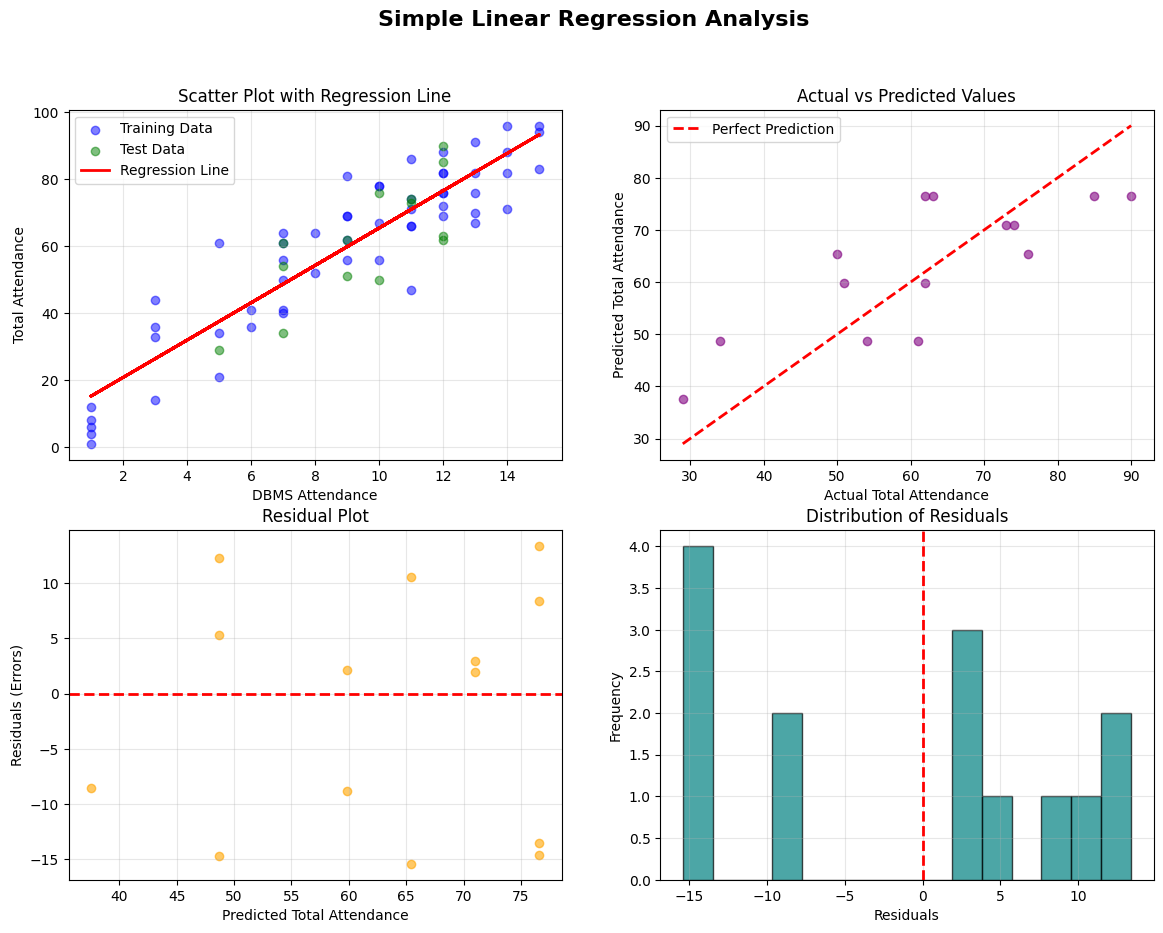

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Simple Linear Regression Analysis', fontsize=16, fontweight='bold')

axes[0, 0].scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
axes[0, 0].scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')
axes[0, 0].plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
axes[0, 0].set_xlabel('DBMS Attendance')
axes[0, 0].set_ylabel('Total Attendance')
axes[0, 0].set_title('Scatter Plot with Regression Line')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_test, y_test_prediction, color='purple', alpha=0.6)
axes[0, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Total Attendance')
axes[0, 1].set_ylabel('Predicted Total Attendance')
axes[0, 1].set_title('Actual vs Predicted Values')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

residuals = y_test - y_test_prediction
axes[1, 0].scatter(y_test_prediction, residuals, color='orange', alpha=0.6)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Total Attendance')
axes[1, 0].set_ylabel('Residuals (Errors)')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(residuals, bins=15, color='teal', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)